# PART 1

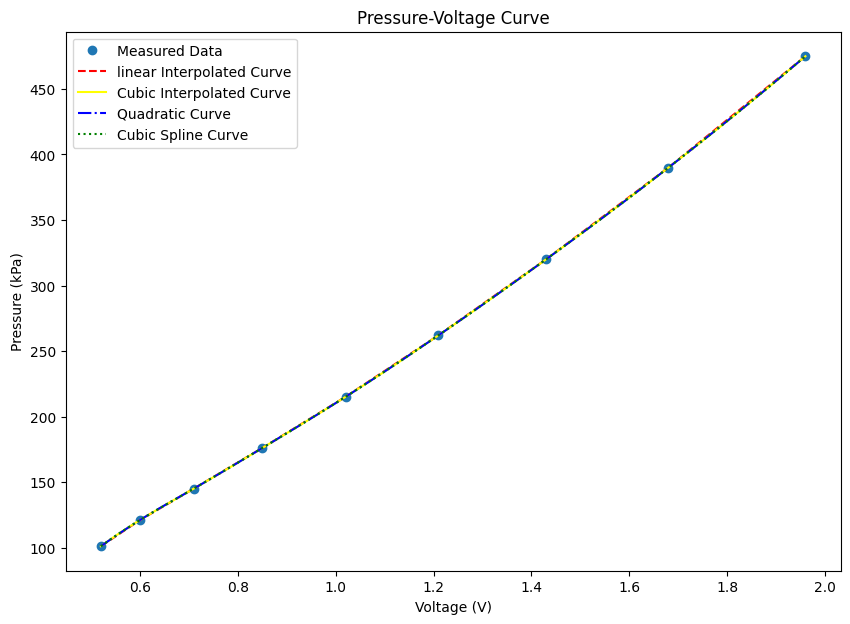

In [4]:
#importing required libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, CubicSpline

#Measured voltage and corresponding pressure values
V = np.array([0.52, 0.60, 0.71, 0.85, 1.02, 1.21, 1.43, 1.68, 1.96])  # Voltage (V)
P = np.array([101, 121, 145, 176, 215, 262, 320, 390, 475])           # Pressure (kPa)


v = np.linspace(0.52, 1.96, 100)

f_linear = interp1d(V, P, kind='linear', fill_value="extrapolate")
f_cubic  = interp1d(V, P, kind='cubic',  fill_value="extrapolate")
f_quadratic = interp1d(V, P, kind='quadratic', fill_value="extrapolate")
cs_func = CubicSpline(V, P)

#functional representation
p_lin = f_linear(v)  #linear function
p_cube = f_cubic(v)  #cubic function
p_quad = f_quadratic(v)  #quadratic function
p_cs = cs_func(v)   #CubicSpline function


plt.figure(figsize=(10,7))
plt.plot(V, P, 'o', label='Measured Data')
plt.plot(v, p_lin, '--', label='linear Interpolated Curve', color='red')
plt.plot(v, p_cube, '-', label='Cubic Interpolated Curve', color='yellow')
plt.plot(v, p_quad, '-.', label='Quadratic Curve', color='blue')
plt.plot(v, p_cs, ':', label='Cubic Spline Curve', color='green')
plt.xlabel('Voltage (V)')
plt.ylabel('Pressure (kPa)')
plt.title('Pressure-Voltage Curve')
plt.legend(loc="best")
plt.show()


so, we can say from graph, measured data from sensor appear linear with respect to the pressure. here we used interp1d(linear, cubic, quadratic) and CubicSpline method to interpolate.

yeah , the given information is adequate for the calibration curve.

a physically reasonable callibration curve should be smooth linear, it should not bend abruptly.

- The data show a monotonic increasing trend.The relationship is approximately linear over the calibration range.However, slight curvature is visible so the response is not perfectly linear.

- The dataset is sufficient to construct a calibration curve, but the functional form is not unique and depends on the interpolation method used.

- A physically reasonable calibration curve should be smooth, continuous, monotonic, and free from oscillations, ensuring physically realistic behavior between measured points.

#PART 2

In [5]:
#Voltage signal "outside" the calibration data
V_out = np.array([0.47, 0.50, 2.05, 2.15, 2.30])
#reference pressure values
P_ref = np.array([96, 99, 505, 540, 610])

#P_out calculated from the CubicSpline extrapolation
P_out = cs_func(V_out)

#P_out calculated from the interp1d extrapolation
P_out_lin  = f_linear(V_out)
P_out_cube  = f_cubic(V_out)
P_out_quad = f_quadratic(V_out)

print(f"P_ref: {P_ref}")
print(f"P_out: {P_out}")
print(f"P_out_lin: {P_out_lin}")
print(f"P_out_cube: {P_out_cube}")
print(f"P_Out_quad: {P_out_quad}")

P_ref: [ 96  99 505 540 610]
P_out: [ 86.2333803   95.34789021 504.13146043 537.6748178  590.51226329]
P_out_lin: [ 88.5         96.         502.32142857 532.67857143 578.21428571]
P_out_cube: [ 86.2333803   95.34789021 504.13146043 537.6748178  590.51226329]
P_Out_quad: [ 87.17898959  95.59353526 503.85676902 536.79586578 587.93349792]


In [6]:
#error analysis
err_cs = np.abs(P_out - P_ref)
err_lin = np.abs(P_out_lin - P_ref)
err_cube = np.abs(P_out_cube - P_ref)
err_quad = np.abs(P_out_quad - P_ref)

print(f"error_cs: {err_cs}")
print(f"error_lin: {err_lin}")
print(f"error_cub: {err_cube}")
print(f"error_quad: {err_quad}")

error_cs: [ 9.7666197   3.65210979  0.86853957  2.3251822  19.48773671]
error_lin: [ 7.5         3.          2.67857143  7.32142857 31.78571429]
error_cub: [ 9.7666197   3.65210979  0.86853957  2.3251822  19.48773671]
error_quad: [ 8.82101041  3.40646474  1.14323098  3.20413422 22.06650208]


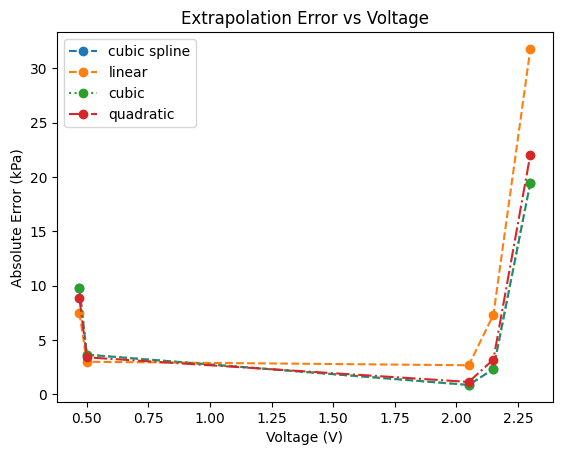

In [7]:
#Extrapolation Error Analysis
plt.plot(V_out, err_cs, '--o', label="cubic spline")
plt.plot(V_out, err_lin, '--o', label="linear")
plt.plot(V_out, err_cube, ':o', label="cubic")
plt.plot(V_out, err_quad, '-.o', label="quadratic")

plt.xlabel("Voltage (V)")
plt.ylabel("Absolute Error (kPa)")
plt.title("Extrapolation Error vs Voltage")
plt.legend(loc="best")
plt.show()

Based on comparison with reference values, cubic spline extrapolation provides the most reliable estimates with minimal error near the calibration boundaries. Linear and quadratic methods exhibit larger deviations as the extrapolation distance increases. This highlights the inherent uncertainty associated with extrapolation beyond measured data.

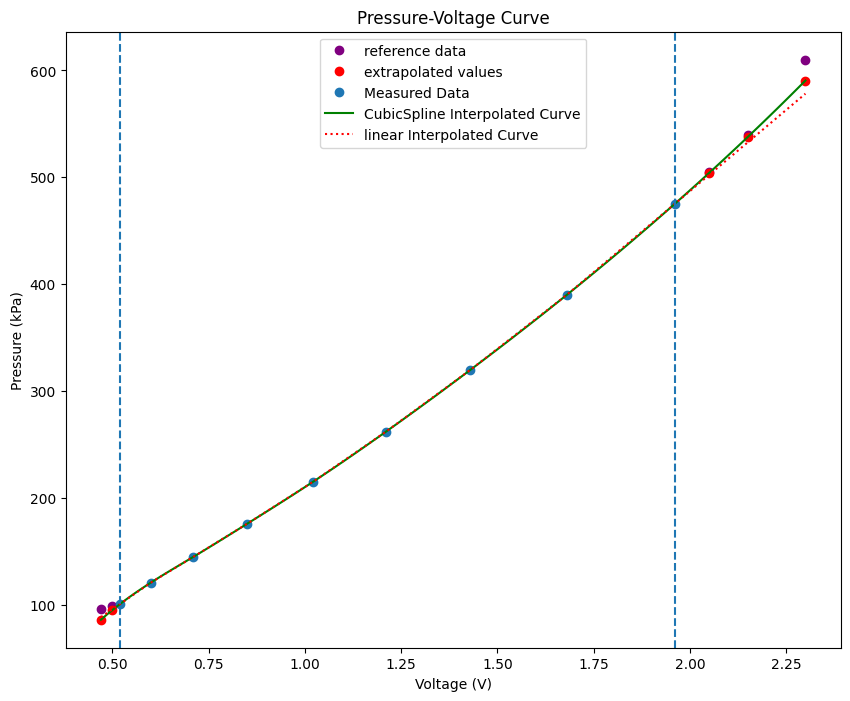

In [8]:
v_ext = np.linspace(0.47, 2.30, 100)
p_ext = cs_func(v_ext)
p_ext_lin = f_linear(v_ext)
p_ext_cube = f_cubic(v_ext)
p_ext_quad = f_quadratic(v_ext)


plt.figure(figsize=(10,8))

plt.plot(V_out, P_ref, 'o', color='purple', label='reference data') #reference data
plt.plot(V_out, P_out_cube, 'o', color='red', label='extrapolated values'
)  #extrapolated data

plt.plot(V, P, 'o', label='Measured Data')
plt.plot(v_ext, p_ext, '-', label='CubicSpline Interpolated Curve', color='green')
plt.plot(v_ext, p_ext_lin, ':', label='linear Interpolated Curve', color='red')
# plt.plot(v_ext, p_ext_cube, '-', label='Cubic Interpolated Curve', color='yellow')
# plt.plot(v_ext, p_ext_quad, '-.', label='Quadratic Curve', color='blue')

#To demonstrate extrapolation clearly, drawing calibration range limits
plt.axvline(0.52, linestyle="--")
plt.axvline(1.96, linestyle="--")

plt.xlabel('Voltage (V)')
plt.ylabel('Pressure (kPa)')
plt.title('Pressure-Voltage Curve')
plt.legend(loc='upper center')
plt.show()

> Smoother interpolation schemes (such as cubic splines) generally produce better extrapolation near the calibration range because they preserve slope continuity. However, accuracy deteriorates as the extrapolation distance increases.

>Extrapolation becomes more uncertain as we move farther away from the calibration range. Predictions near the known data points may still be reasonable, but far outside the measured region the error can grow quickly, making the results less reliable.



>Since extrapolation predicts behavior outside the measured range, the resulting curve may be numerically smooth yet physically inaccurate. A well-behaved mathematical curve does not guarantee physical validity.

#PART 3


Gas volume$V$ is related to the piston displacement by: $$V(x) = V_0 - Ax$$
where $V_0 = 50cm^2$ and $A = 5cm^2$

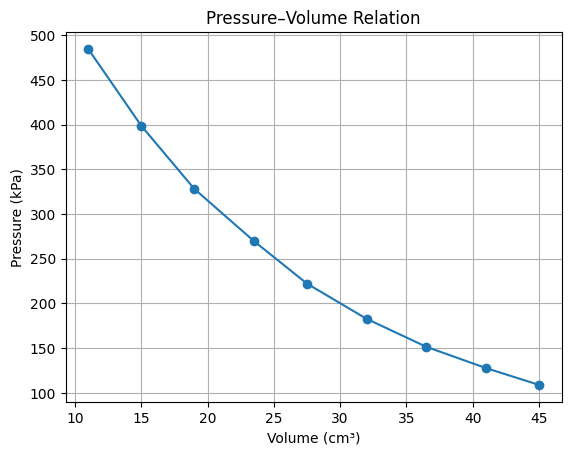

Volume: [45.  41.  36.5 32.  27.5 23.5 19.  15.  11. ]
Pressure: [108.93244278 127.74799715 151.51622358 182.75776669 222.16708847
 269.71161414 328.15906098 398.74011728 484.60375442]


In [11]:
#Measured voltage and corresponding displacement values
Volt_V = np.array([0.55, 0.63, 0.74, 0.88, 1.05, 1.24, 1.46, 1.71, 1.99]) #V
Disp_X = np.array([1.0, 1.8, 2.7, 3.6, 4.5, 5.3, 6.2, 7.0, 7.8])   #Cm


V_0 = 50  #initial volume (cm^3)
A = 5     #piston area (cm^2)

#Defining function for calculating Volume
def gas_volume(V_0, A, Disp_X):
  return V_0 - A * Disp_X
Volume = gas_volume(V_0, A, Disp_X)

#using CubicSpline function(calibration curve) for calculating the pressure from voltage measurement
Pressure = cs_func(Volt_V)

plt.plot(Volume, Pressure, 'o-')
plt.xlabel('Volume (cm³)')
plt.ylabel('Pressure (kPa)')
plt.title('Pressure–Volume Relation')
plt.grid(True)
plt.show()

print(f"Volume: {Volume}")
print(f"Pressure: {Pressure}")


> For an ideal isothermal process, pressure and volume are inversely related. Using the calibration curve to convert voltage into pressure and the displacement data to compute volume, the reconstructed P–V curve is smooth and physically consistent. Although the curve does not show a perfect inverse relation, it reflects realistic experimental behavior.


> The obtained pressure–volume relation is physically reasonable and free from abrupt or unphysical variations. Deviations from the ideal isothermal relation may arise from experimental conditions, sensor calibration, and numerical interpolation.

#PART 4


Suppose the gas approximately follows a polytropic relation:
$$PV^{γ} = constant$$


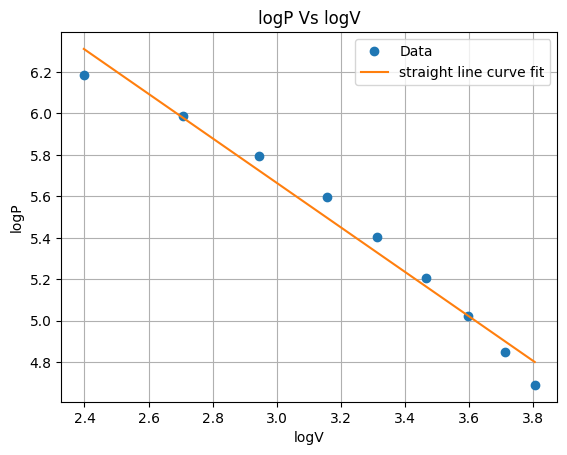

Value of γ is: 1.0715270142502273


In [12]:
#taking log of volume and pressure
logV = np.log(Volume)
logP = np.log(Pressure)

slope, intercept = np.polyfit(logV, logP, 1)

def log_straight_line(logV, slope , intercept):
    return (slope * logV) + intercept
logp = log_straight_line(logV, slope, intercept)

gamma = -slope


plt.plot(logV, logP, 'o', label='Data')
plt.plot(logV, logp, label="straight line curve fit")
plt.title("logP Vs logV")
plt.xlabel("logV")
plt.ylabel("logP")
plt.legend()
plt.grid(True)
plt.show()

#print value of gamma
print(f"Value of γ is: {gamma}")

Starting from the polytropic relation
$PV^{γ} = constant$
=constant, taking logarithms yields a linear relation between
$logP$ and $logV$. The slope of the best-fit line gives value of
$γ$.

The extracted polytropic exponent γ appears approximately constant across the dataset and is close to 1. This suggests that the process is nearly isothermal, consistent with the assumption of constant temperature during the experiment.

γ was obtained by fitting a straight line to the
$logP$ vs $logV$ plot. Because pressure values depend on the interpolation method used for calibration, the inferred γ may vary slightly with the numerical technique employed.